# K-Means clustering algorithm

Initial centroids: [(2, 10), (5, 8), (1, 2)]
Clusters after first iteration: [[(2, 10)], [(8, 4), (5, 8), (7, 5), (6, 4), (4, 9)], [(2, 5), (1, 2)]]
New centroids after first iteration: [[2.0, 10.0], [6.0, 6.0], [1.5, 3.5]]


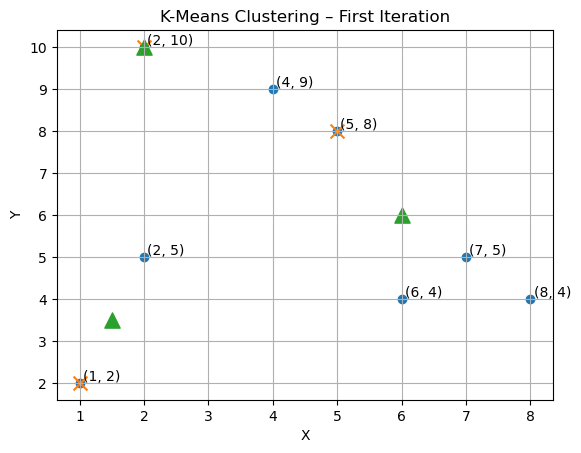

In [1]:
import random, math
import matplotlib.pyplot as plt

# -----------------------------
# Distance and mean functions
# -----------------------------
def dist(a, b):
    return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))

def mean(points):
    return [sum(x[i] for x in points)/len(points) for i in range(len(points[0]))]

# -----------------------------
# Dataset from your notebook
# -----------------------------
points = [(2,10),(2,5),(8,4),(5,8),(7,5),(6,4),(1,2),(4,9)]
k = 3

# Initial centroids (assumed for lab problem)
centroids = [(2,10),(5,8),(1,2)]

# -----------------------------
# First Iteration of K-Means
# -----------------------------
clusters = [[] for _ in range(k)]

for p in points:
    d = [dist(p, c) for c in centroids]
    clusters[d.index(min(d))].append(p)

new_centroids = [mean(cluster) for cluster in clusters]

print("Initial centroids:", centroids)
print("Clusters after first iteration:", clusters)
print("New centroids after first iteration:", new_centroids)

# -----------------------------
# Plotting diagram
# -----------------------------
x = [p[0] for p in points]
y = [p[1] for p in points]

plt.figure()
plt.scatter(x, y, marker='o')                      # data points
plt.scatter([c[0] for c in centroids],
            [c[1] for c in centroids], marker='x', s=100)   # initial centroids
plt.scatter([c[0] for c in new_centroids],
            [c[1] for c in new_centroids], marker='^', s=120)  # new centroids

for p in points:
    plt.text(p[0]+0.05, p[1]+0.05, str(p))

plt.title("K-Means Clustering – First Iteration")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()


# EM algorithm

In [2]:
import math

# Dataset: (Heads, Tails)
data = [(5,5), (9,1), (8,2), (4,6), (7,3)]

theta_A = 0.6
theta_B = 0.5
pi_A = 0.5
pi_B = 0.5

def prob(h, t, theta):
    return (theta**h) * ((1-theta)**t)

gamma_A = []
gamma_B = []

# -------- E-Step --------
for h, t in data:
    pA = pi_A * prob(h, t, theta_A)
    pB = pi_B * prob(h, t, theta_B)
    total = pA + pB
    gamma_A.append(pA / total)
    gamma_B.append(pB / total)

# -------- M-Step --------
new_theta_A = sum(gamma_A[i] * data[i][0] for i in range(5)) / \
              sum(gamma_A[i] * 10 for i in range(5))

new_theta_B = sum(gamma_B[i] * data[i][0] for i in range(5)) / \
              sum(gamma_B[i] * 10 for i in range(5))

print("Theta A after 1st iteration:", round(new_theta_A,4))
print("Theta B after 1st iteration:", round(new_theta_B,4))


Theta A after 1st iteration: 0.713
Theta B after 1st iteration: 0.5813


# LSI Algorithm

In [11]:
import math

# Documents and Query
docs = [
    "shipment of gold damaged in a fire".split(),
    "delivery of silver arrived in a silver truck".split(),
    "shipment of gold arrived in a truck".split()
]

query = "gold silver truck".split()

# Vocabulary (fixed order as notebook)
terms = ["shipment","of","gold","damaged","in","a",
         "fire","delivery","silver","arrived","truck"]

N = 3

# IDF calculation
idf = {t: round(math.log10(N / sum(t in d for d in docs)), 3)
       if sum(t in d for d in docs) != 0 else 0 for t in terms}

# TF-IDF vector
def tfidf(words):
    return [round(words.count(t) * idf[t], 3) for t in terms]

D1 = tfidf(docs[0])
D2 = tfidf(docs[1])
D3 = tfidf(docs[2])
Q  = tfidf(query)

# Similarity (dot product)
def similarity(d, q):
    return round(sum(d[i] * q[i] for i in range(len(q))), 3)

# --------- Output (ONLY THIS) ----------
print("Similarity Calculation:")
print("SC(D1,Q) =", similarity(D1, Q))
print("SC(D2,Q) =", similarity(D2, Q))
print("SC(D3,Q) =", similarity(D3, Q))


Similarity Calculation:
SC(D1,Q) = 0.031
SC(D2,Q) = 0.486
SC(D3,Q) = 0.062
